In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

import cv2
from pathlib import Path
import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Dataset handler for signal images 

In [3]:
class SignalImageDataset:
    
    
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.image_paths = []
        self.labels = []
        self.label_encoder = LabelEncoder()
        self.load_dataset()
    
    def load_dataset(self):
        """Load all images and their corresponding labels"""
        print("Loading dataset...")
        
        for machine_folder in self.dataset_path.iterdir():
            if machine_folder.is_dir():
                machine_name = machine_folder.name
                print(f"Loading images from {machine_name}...")
                
                for image_path in machine_folder.glob("*.png"):
                    self.image_paths.append(str(image_path))
                    self.labels.append(machine_name)
        
        # Encode labels
        self.labels_encoded = self.label_encoder.fit_transform(self.labels)
        
        print(f"Dataset loaded: {len(self.image_paths)} images")
        print(f"Classes: {list(self.label_encoder.classes_)}")
        print(f"Class distribution:")
        unique, counts = np.unique(self.labels, return_counts=True)
        for cls, count in zip(unique, counts):
            print(f"  {cls}: {count} images")
    
    def load_and_preprocess_image(self, image_path, target_size=(150, 400)):
        """Load and preprocess a single image"""
        try:
            # Load image
            img = cv2.imread(image_path)
            if img is None:
                return None
            
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # FIXED: OpenCV resize expects (width, height), so we need to swap
            # target_size is (height, width) = (150, 400)
            # cv2.resize expects (width, height) = (400, 150)
            img = cv2.resize(img, (target_size[1], target_size[0]))
            
            # Normalize pixel values to [-1, 1] for better training stability
            img = img.astype(np.float32) / 127.5 - 1.0
            
            return img
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None
    
    def get_data_arrays(self, target_size=(150, 400)):
        """Convert dataset to numpy arrays for training"""
        print("Converting images to arrays...")
        
        X = []
        y = []
        
        for i, (img_path, label) in enumerate(zip(self.image_paths, self.labels_encoded)):
            if i % 100 == 0:
                print(f"Processed {i}/{len(self.image_paths)} images")
            
            img = self.load_and_preprocess_image(img_path, target_size)
            if img is not None:
                X.append(img)
                y.append(label)
        
        X = np.array(X)
        y = np.array(y)
        
        # Debug: Print actual shapes
        print(f"Final X shape: {X.shape}")
        print(f"Final y shape: {y.shape}")
        
        return X, y


## CNN model for signal classification 

In [4]:
class SignalCNNClassifier:
    
    
    def __init__(self, num_classes, input_shape=(150, 400, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.model = None
        self.history = None
        print(f"Expected input shape: {input_shape}")
        self.build_model()
    
    def build_model(self):
        """Build CNN architecture optimized for signal images"""
        
        # Build model with explicit Input layer
        inputs = layers.Input(shape=self.input_shape)
        
        # First Convolutional Block
        x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Second Convolutional Block
        x = layers.Conv2D(64, (3, 3), activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Third Convolutional Block
        x = layers.Conv2D(128, (3, 3), activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Fourth Convolutional Block
        x = layers.Conv2D(256, (3, 3), activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.3)(x)
        
        # Global Average Pooling
        x = layers.GlobalAveragePooling2D()(x)
        
        # Dense layers
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        
        # Output layer
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)
        
        # Create model
        self.model = models.Model(inputs=inputs, outputs=outputs)
        
        # Compile model with a lower learning rate for better stability
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print("Model built successfully!")
        print(self.model.summary())
    
    def train(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
        """Train the CNN model"""
        
        # Debug: Print shapes before training
        print(f"Training data shape: {X_train.shape}")
        print(f"Validation data shape: {X_val.shape}")
        print(f"Expected input shape: {self.input_shape}")
        
        # Verify shapes match
        if X_train.shape[1:] != self.input_shape:
            raise ValueError(f"Input shape mismatch! Expected {self.input_shape}, got {X_train.shape[1:]}")
        
        # Data augmentation for better generalization
        datagen = ImageDataGenerator(
            rotation_range=3,  # Reduced rotation for signal data
            width_shift_range=0.05,  # Reduced shifts
            height_shift_range=0.05,
            horizontal_flip=False,  # Don't flip signals
            zoom_range=0.05,  # Reduced zoom
            brightness_range=[0.9, 1.1],  # Add brightness variation
            fill_mode='nearest'
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=15,  # Increased patience
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.3,  # More aggressive LR reduction
                patience=7,
                min_lr=1e-7,
                verbose=1
            )
        ]
        
        print("Starting training...")
        
        # Train model
        self.history = self.model.fit(
            datagen.flow(X_train, y_train, batch_size=batch_size),
            steps_per_epoch=len(X_train) // batch_size,
            epochs=epochs,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )
        
        print("Training completed!")
        return self.history
    
    def evaluate(self, X_test, y_test, label_encoder):
        """Evaluate model performance"""
        
        # Predictions
        y_pred_proba = self.model.predict(X_test)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Accuracy
        accuracy = np.mean(y_pred == y_test)
        print(f"Test Accuracy: {accuracy:.4f}")
        
        # Classification report
        class_names = label_encoder.classes_
        report = classification_report(y_test, y_pred, target_names=class_names)
        print("\nClassification Report:")
        print(report)
        
        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45)
        plt.yticks(rotation=45)
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return accuracy, y_pred, y_pred_proba
    
    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Accuracy
        ax1.plot(self.history.history['accuracy'], label='Training Accuracy')
        ax1.plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()
        ax1.grid(True)
        
        # Loss
        ax2.plot(self.history.history['loss'], label='Training Loss')
        ax2.plot(self.history.history['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True)
        
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def save_model(self, filepath):
        """Save the trained model"""
        self.model.save(filepath)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load a pre-trained model"""
        self.model = keras.models.load_model(filepath)
        print(f"Model loaded from {filepath}")


## Advanced signal analysis and Visualization

In [5]:
class SignalAnalyzer:
    
    
    def __init__(self, model, label_encoder, dataset):
        self.model = model
        self.label_encoder = label_encoder
        self.dataset = dataset
    
    def predict_single_image(self, image_path, confidence_threshold=0.5):
        """Predict class for a single signal image"""
        
        # Load and preprocess image
        img = self.dataset.load_and_preprocess_image(image_path)
        if img is None:
            return None, None, None
        
        # Add batch dimension
        img_batch = np.expand_dims(img, axis=0)
        
        # Predict
        predictions = self.model.predict(img_batch, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_idx]
        predicted_class = self.label_encoder.inverse_transform([predicted_class_idx])[0]
        
        # Get all class probabilities
        class_probabilities = {}
        for i, class_name in enumerate(self.label_encoder.classes_):
            class_probabilities[class_name] = predictions[0][i]
        
        return predicted_class, confidence, class_probabilities
    
    def analyze_signal_patterns(self, X_test, y_test, num_samples=5):
        """Analyze and visualize signal patterns for each class"""
        
        plt.figure(figsize=(20, 4 * len(self.label_encoder.classes_)))
        
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            # Get samples from this class
            class_indices = np.where(y_test == class_idx)[0]
            if len(class_indices) == 0:
                continue
            
            sample_indices = np.random.choice(class_indices, 
                                            min(num_samples, len(class_indices)), 
                                            replace=False)
            
            for i, idx in enumerate(sample_indices):
                plt.subplot(len(self.label_encoder.classes_), num_samples, 
                           class_idx * num_samples + i + 1)
                # Denormalize for display
                img_display = (X_test[idx] + 1.0) / 2.0
                plt.imshow(img_display)
                plt.title(f'{class_name}\nSample {i+1}')
                plt.axis('off')
        
        plt.tight_layout()
        plt.savefig('signal_patterns_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def extract_features(self, X, layer_name='global_average_pooling2d'):
        """Extract features from intermediate layer"""
        
        try:
            # Create feature extraction model
            feature_model = keras.Model(
                inputs=self.model.input,
                outputs=self.model.get_layer(layer_name).output
            )
            
            # Extract features
            features = feature_model.predict(X, verbose=0)
            return features
        except Exception as e:
            print(f"Error extracting features: {e}")
            # Fallback: use model predictions as features
            return self.model.predict(X, verbose=0)
    
    def visualize_feature_space(self, X_test, y_test):
        """Visualize feature space using t-SNE"""
        try:
            from sklearn.manifold import TSNE
            from sklearn.decomposition import PCA
            
            # Extract features
            features = self.extract_features(X_test)
            
            # Reduce dimensions first with PCA, then t-SNE
            if features.shape[1] > 50:
                pca = PCA(n_components=50)
                features_pca = pca.fit_transform(features)
            else:
                features_pca = features
            
            # Apply t-SNE
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_test)//4))
            features_2d = tsne.fit_transform(features_pca)
            
            # Plot
            plt.figure(figsize=(12, 8))
            colors = plt.cm.Set3(np.linspace(0, 1, len(self.label_encoder.classes_)))
            
            for class_idx, (class_name, color) in enumerate(zip(self.label_encoder.classes_, colors)):
                mask = y_test == class_idx
                if np.sum(mask) > 0:  # Only plot if class has samples
                    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                               c=[color], label=class_name, alpha=0.7, s=20)
            
            plt.title('Feature Space Visualization (t-SNE)')
            plt.xlabel('t-SNE Component 1')
            plt.ylabel('t-SNE Component 2')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('feature_space_visualization.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        except ImportError:
            print("scikit-learn required for feature visualization. Install with: pip install scikit-learn")
        except Exception as e:
            print(f"Error in feature space visualization: {e}")


## Main Function 

Starting Signal Computer Vision Classification Pipeline

 Step 1: Loading Dataset
Loading dataset...
Loading images from PT41...
Loading images from PT77...
Loading images from PT76...
Loading images from PT71...
Loading images from PT103...
Loading images from PT54...
Loading images from PT74...
Loading images from PT154...
Loading images from PT57...
Dataset loaded: 900 images
Classes: ['PT103', 'PT154', 'PT41', 'PT54', 'PT57', 'PT71', 'PT74', 'PT76', 'PT77']
Class distribution:
  PT103: 100 images
  PT154: 100 images
  PT41: 100 images
  PT54: 100 images
  PT57: 100 images
  PT71: 100 images
  PT74: 100 images
  PT76: 100 images
  PT77: 100 images

 Step 2: Preparing Data Arrays
Converting images to arrays...
Processed 0/900 images
Processed 100/900 images
Processed 200/900 images
Processed 300/900 images
Processed 400/900 images
Processed 500/900 images
Processed 600/900 images
Processed 700/900 images
Processed 800/900 images
Final X shape: (900, 150, 400, 3)
Final y shape: (900,)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 400, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 398, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 398, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 197, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 197, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 46, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 46, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 23, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 23, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,32

 Total params: 658,633 (2.51 MB)

 Trainable params: 656,137 (2.50 MB)

 Non-trainable params: 2,496 (9.75 KB)

None
Training data shape: (630, 150, 400, 3)
Validation data shape: (135, 150, 400, 3)
Expected input shape: (150, 400, 3)
Starting training...
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 674ms/step - accuracy: 0.1312 - loss: 3.1713 - val_accuracy: 0.1111 - val_loss: 2.2055 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0625 - loss: 3.5433 - val_accuracy: 0.1111 - val_loss: 2.2061 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 653ms/step - accuracy: 0.1324 - loss: 3.0450 - val_accuracy: 0.0519 - val_loss: 2.2428 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0625 - loss: 2.8259 - val_accuracy: 0.1037 - val_loss: 2.2418 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 688ms/step - accuracy: 0.1698 - loss: 2.8535 - val_accuracy: 0.1111 - val_loss: 2.2638 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.1250 - loss: 2.7943 - val_accu

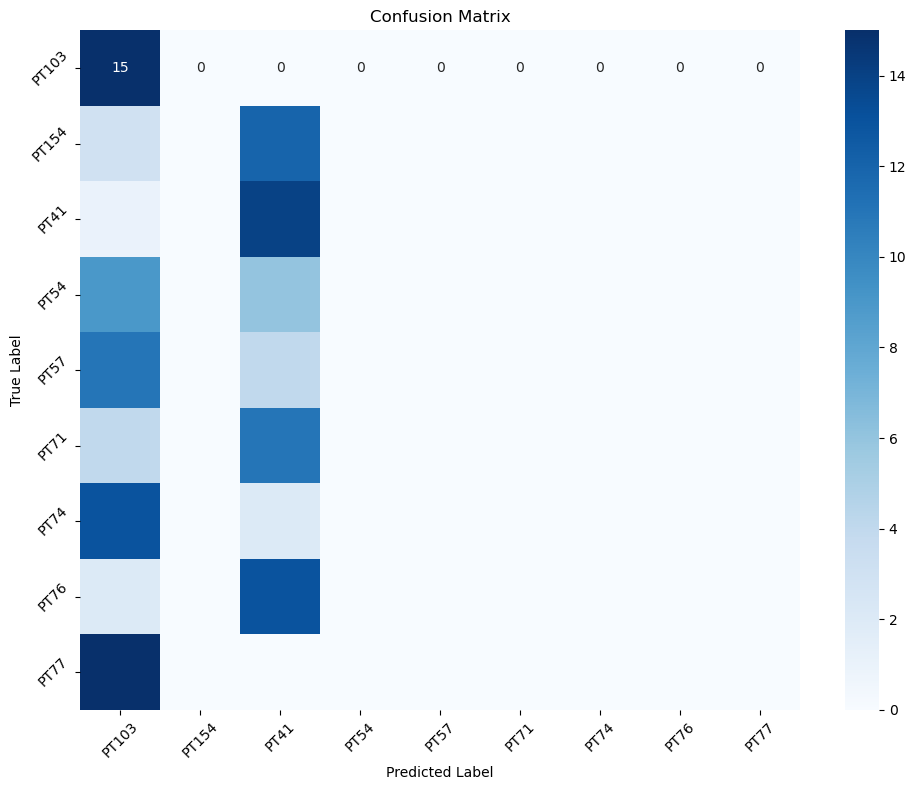

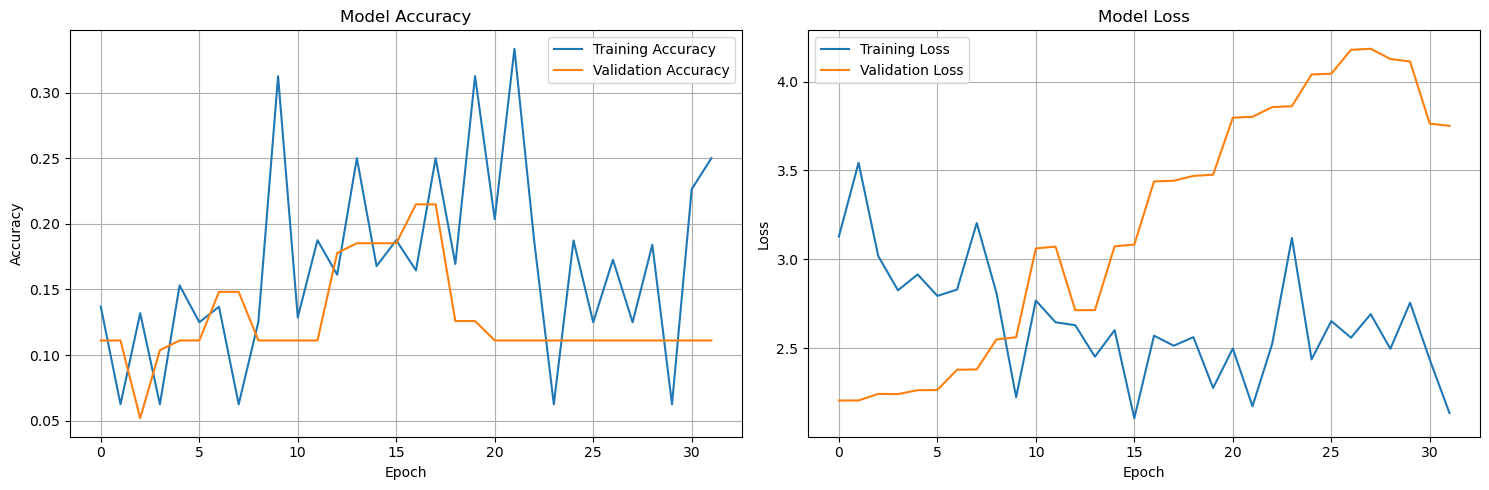


 Step 6: Advanced Signal Analysis


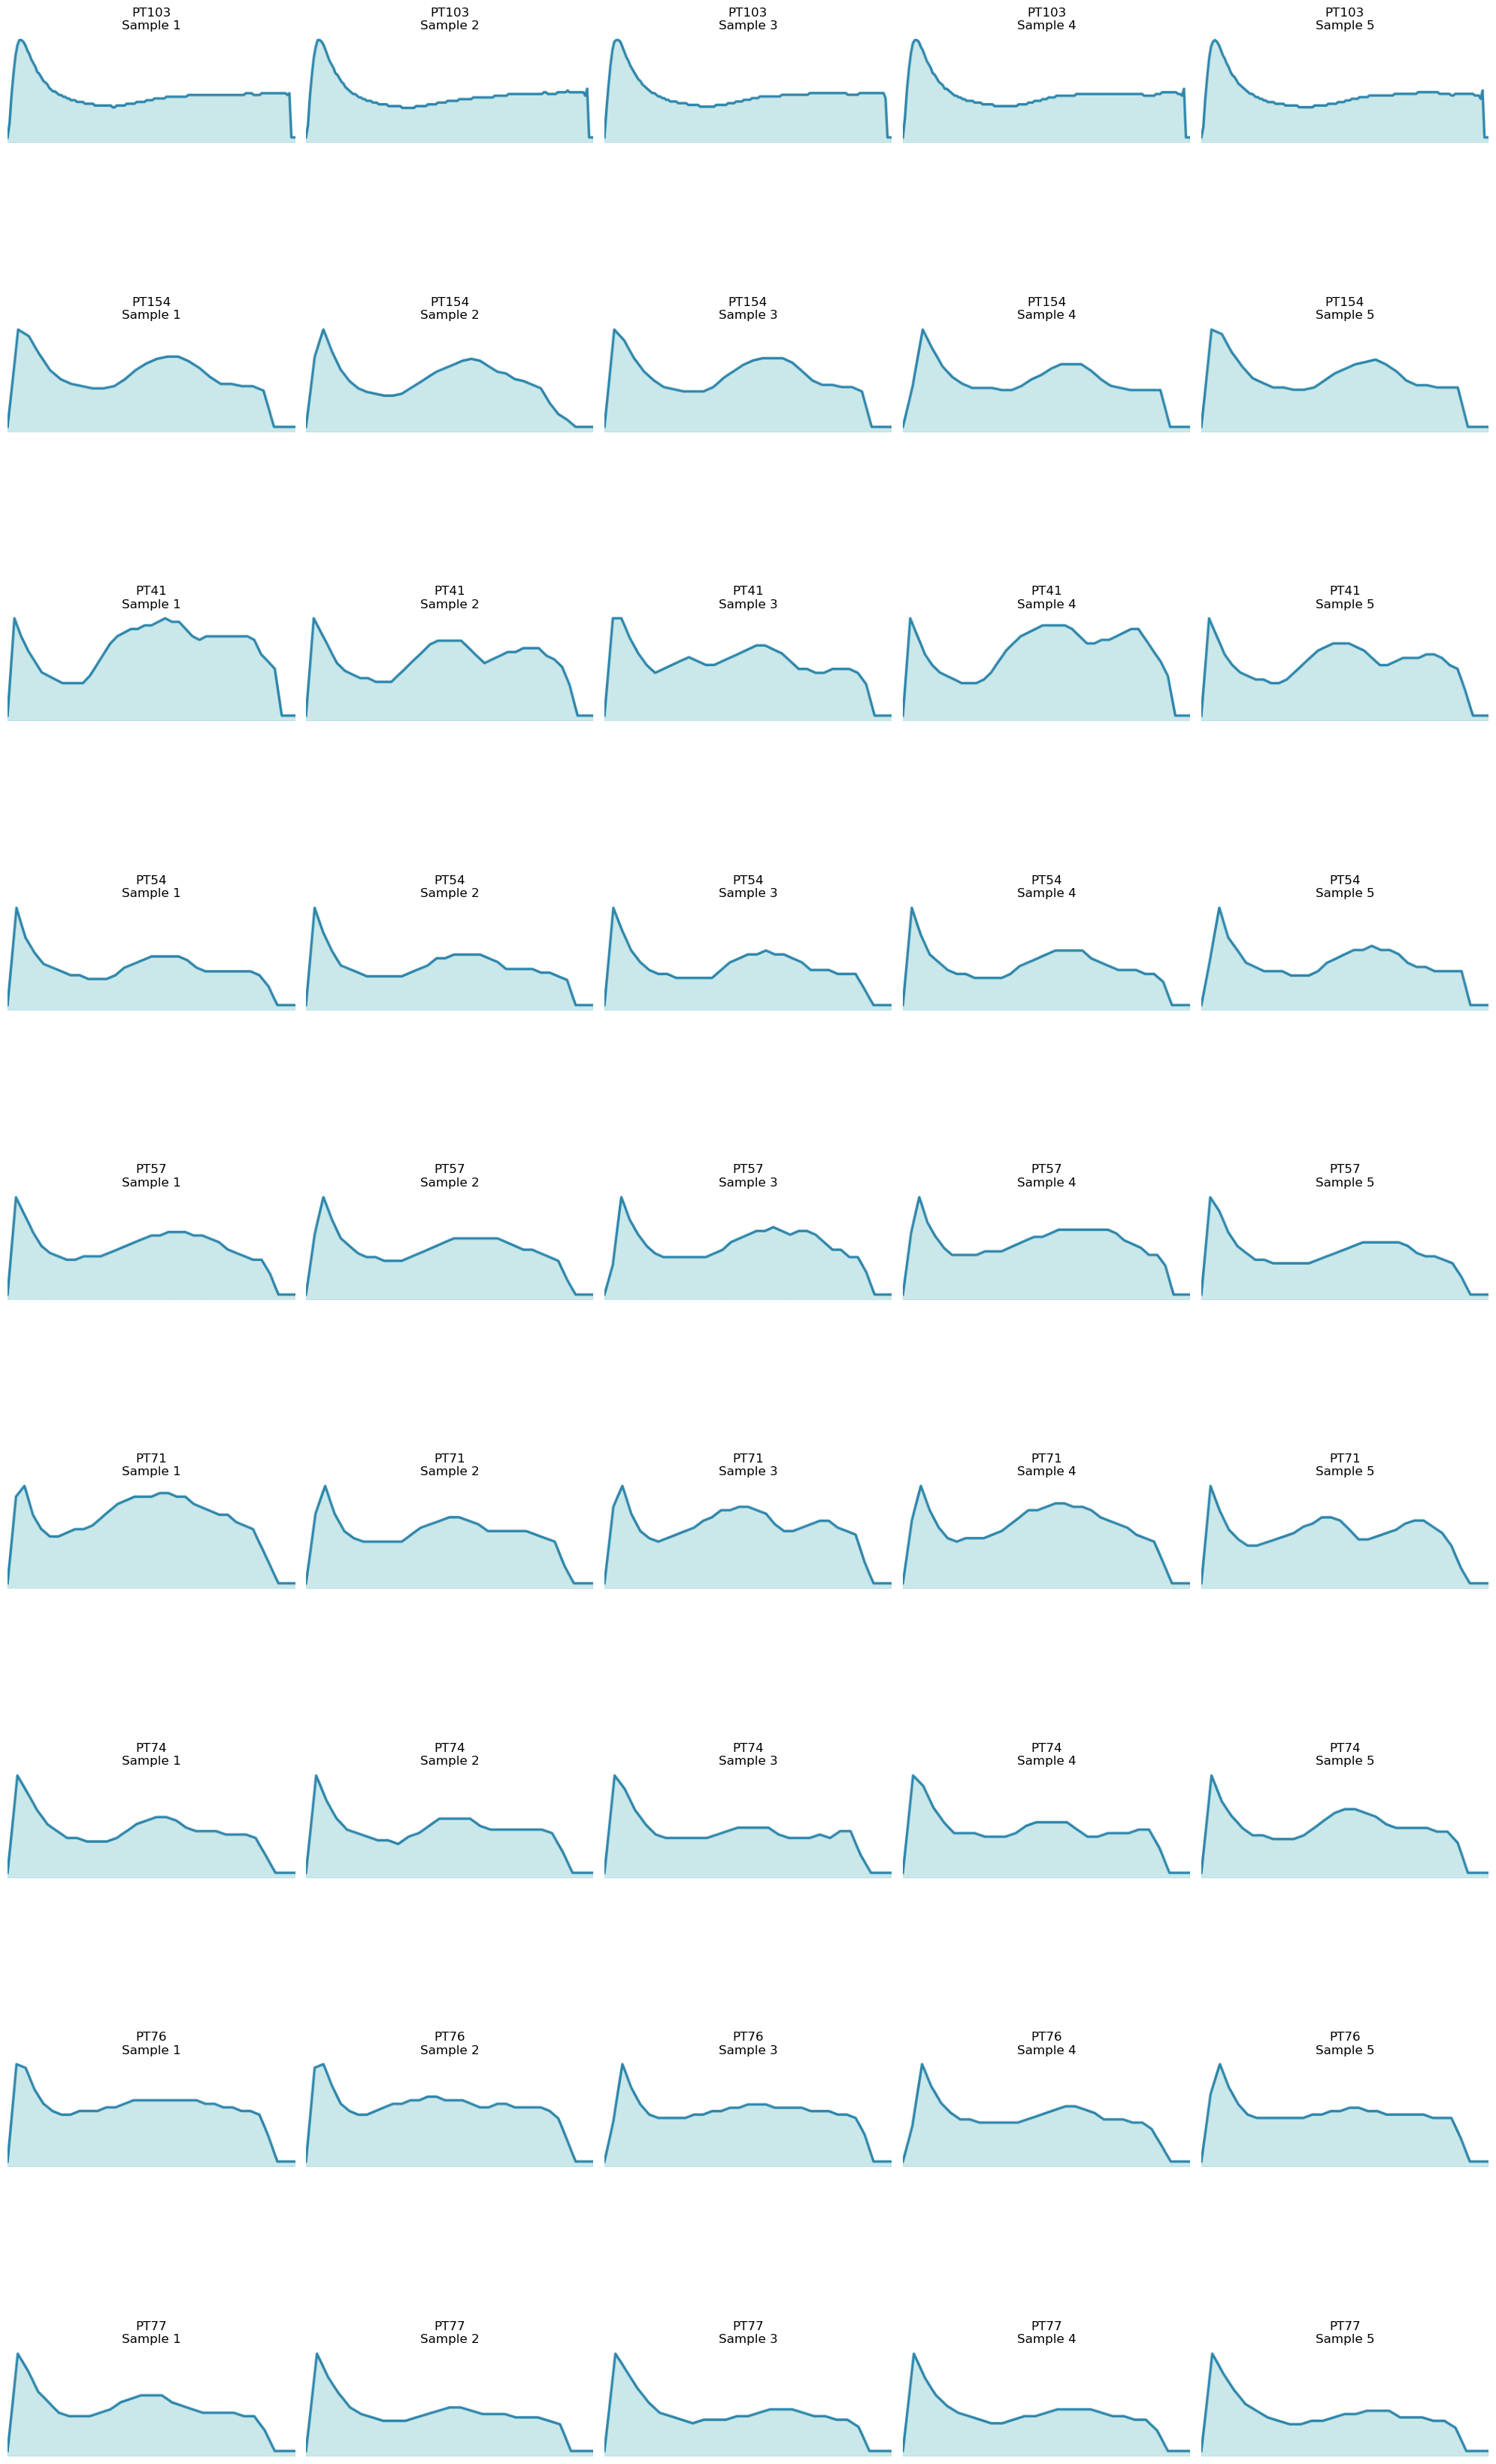

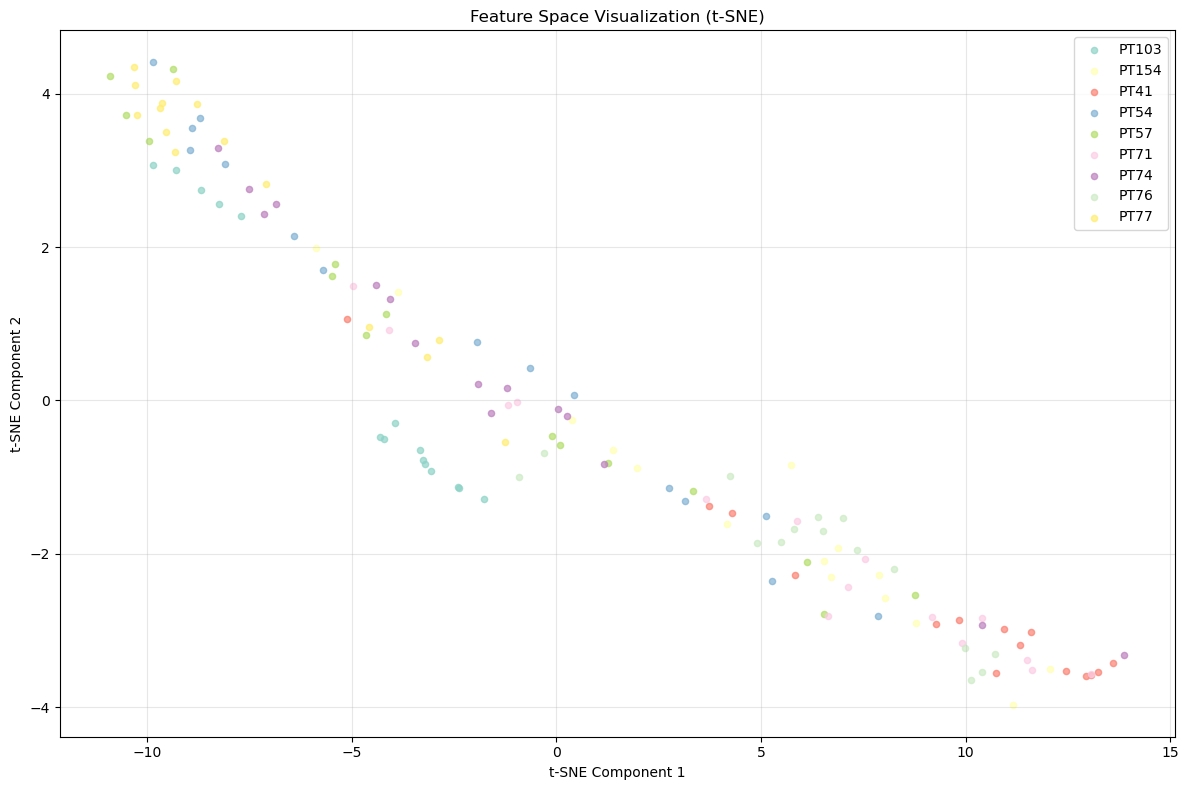


 Step 7: Saving Model and Components
Model saved to signal_classifier_model.h5
Label encoder saved to label_encoder.pkl

 Step 8: Demo - Testing Prediction on Sample Images

Sample 1:
  Actual: PT54
  Predicted: PT41
  Confidence: 0.4280
  Top 3 predictions:
    PT41: 0.4280
    PT103: 0.4229
    PT154: 0.0700

Sample 2:
  Actual: PT57
  Predicted: PT103
  Confidence: 0.4348
  Top 3 predictions:
    PT103: 0.4348
    PT41: 0.4172
    PT154: 0.0685

Sample 3:
  Actual: PT74
  Predicted: PT103
  Confidence: 0.4514
  Top 3 predictions:
    PT103: 0.4514
    PT41: 0.3967
    PT154: 0.0660

 PIPELINE COMPLETED SUCCESSFULLY!
 Final Test Accuracy: 0.2148
 Number of Classes: 9
 Model saved as: signal_classifier_model.h5
 Label encoder saved as: label_encoder.pkl

 Generated Files:
  - confusion_matrix.png
  - training_history.png
  - signal_patterns_analysis.png
  - feature_space_visualization.png

 Tips to improve accuracy:
  - Check if images are properly labeled
  - Increase dataset size i

In [6]:
def main():
    
    # Configuration
    DATASET_PATH = '/Users/anamikasaroha/Energy7_Week1/week_6/signal_dataset_images_v2'  # Your dataset path
    MODEL_SAVE_PATH = 'signal_classifier_model.h5'
    LABEL_ENCODER_PATH = 'label_encoder.pkl'
    TARGET_SIZE = (150, 400)  # height, width
    
    print("Starting Signal Computer Vision Classification Pipeline")
    print("=" * 60)
    
    try:
        # Step 1: Load Dataset
        print("\n Step 1: Loading Dataset")
        dataset = SignalImageDataset(DATASET_PATH)
        
        # Check if dataset is loaded properly
        if len(dataset.image_paths) == 0:
            print(" No images found in dataset! Please check the dataset path.")
            return None, None, None
        
        # Step 2: Prepare Data
        print("\n Step 2: Preparing Data Arrays")
        X, y = dataset.get_data_arrays(target_size=TARGET_SIZE)
        
        print(f"Dataset shape: X={X.shape}, y={y.shape}")
        
        # Check for class imbalance
        unique, counts = np.unique(y, return_counts=True)
        print("\nClass distribution:")
        for i, (cls_idx, count) in enumerate(zip(unique, counts)):
            cls_name = dataset.label_encoder.inverse_transform([cls_idx])[0]
            print(f"  {cls_name}: {count} samples ({count/len(y)*100:.1f}%)")
        
        # Step 3: Split Data
        print("\n Step 3: Splitting Data")
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
        )
        
        print(f"Train: {X_train.shape[0]} samples")
        print(f"Validation: {X_val.shape[0]} samples") 
        print(f"Test: {X_test.shape[0]} samples")
        
        # Step 4: Build and Train Model
        print("\n Step 4: Building and Training CNN Model")
        num_classes = len(dataset.label_encoder.classes_)
        print(f"Number of classes: {num_classes}")
        
        classifier = SignalCNNClassifier(num_classes, input_shape=TARGET_SIZE + (3,))
        
        # Train model with more epochs for better convergence
        history = classifier.train(X_train, y_train, X_val, y_val, epochs=50, batch_size=16)
        
        # Step 5: Evaluate Model
        print("\n Step 5: Evaluating Model")
        accuracy, y_pred, y_pred_proba = classifier.evaluate(X_test, y_test, dataset.label_encoder)
        
        # Plot training history
        classifier.plot_training_history()
        
        # Step 6: Advanced Analysis
        print("\n Step 6: Advanced Signal Analysis")
        analyzer = SignalAnalyzer(classifier.model, dataset.label_encoder, dataset)
        
        # Analyze signal patterns
        analyzer.analyze_signal_patterns(X_test, y_test)
        
        # Visualize feature space
        analyzer.visualize_feature_space(X_test, y_test)
        
        # Step 7: Save Model and Components
        print("\n Step 7: Saving Model and Components")
        classifier.save_model(MODEL_SAVE_PATH)
        
        # Save label encoder
        with open(LABEL_ENCODER_PATH, 'wb') as f:
            pickle.dump(dataset.label_encoder, f)
        
        print(f"Label encoder saved to {LABEL_ENCODER_PATH}")
        
        # Step 8: Demo - Predict New Images
        print("\n Step 8: Demo - Testing Prediction on Sample Images")
        
        # Test on a few random images from test set
        num_samples = min(3, len(X_test))
        sample_indices = np.random.choice(len(X_test), num_samples, replace=False)
        
        for i, idx in enumerate(sample_indices):
            # Save test image temporarily
            temp_image_path = f'temp_test_image_{i}.png'
            # Denormalize for saving
            img_save = (X_test[idx] + 1.0) / 2.0
            plt.imsave(temp_image_path, img_save)
            
            # Predict
            predicted_class, confidence, class_probabilities = analyzer.predict_single_image(temp_image_path)
            actual_class = dataset.label_encoder.inverse_transform([y_test[idx]])[0]
            
            print(f"\nSample {i+1}:")
            print(f"  Actual: {actual_class}")
            print(f"  Predicted: {predicted_class}")
            print(f"  Confidence: {confidence:.4f}")
            print(f"  Top 3 predictions:")
            sorted_probs = sorted(class_probabilities.items(), key=lambda x: x[1], reverse=True)[:3]
            for cls, prob in sorted_probs:
                print(f"    {cls}: {prob:.4f}")
            
            # Clean up temp file
            if os.path.exists(temp_image_path):
                os.remove(temp_image_path)
        
        # Final Summary
        print("\n" + "=" * 60)
        print(" PIPELINE COMPLETED SUCCESSFULLY!")
        print("=" * 60)
        print(f" Final Test Accuracy: {accuracy:.4f}")
        print(f" Number of Classes: {num_classes}")
        print(f" Model saved as: {MODEL_SAVE_PATH}")
        print(f" Label encoder saved as: {LABEL_ENCODER_PATH}")
        print("\n Generated Files:")
        print("  - confusion_matrix.png")
        print("  - training_history.png") 
        print("  - signal_patterns_analysis.png")
        print("  - feature_space_visualization.png")
        
        # Performance recommendations
        if accuracy < 0.7:
            print("\n Tips to improve accuracy:")
            print("  - Check if images are properly labeled")
            print("  - Increase dataset size if possible")
            print("  - Try different image preprocessing")
            print("  - Consider transfer learning with pre-trained models")
            print("  - Experiment with different model architectures")
        
        return classifier, analyzer, dataset
        
    except Exception as e:
        print(f" Error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

if __name__ == "__main__":
    classifier, analyzer, dataset = main()